# 3D random coil model

In [14]:
%matplotlib inline 
from math import sin
from math import cos
from math import radians
import os

import numpy as np
import pandas as pd 

import seaborn as sns
from matplotlib import pyplot as plt

import pychrtrace.image_processing_functions as ip
import pychrtrace.trace_analysis_functions as tr
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Setup parameters for simulation.

In [30]:
g_dist_myc_tad = [101.04831155, 180.9838366 , 213.93465326,  62.95758484, 117.96738095, 47.04150883, 114.01559434, 174.39652885, 119.71141301] #Genomic spacing TAD-scale library
g_dist_myc_loop = [10, 10, 10, 10, 10, 10, 10, 10, 10] #Genomic spacing loop-scale library
deg = 360                           # Contraint on angle choice for direction. Generally 360 for no persistance.
name = "MYC_TAD_10pos"  # Prefix of output filename.
g_dist = g_dist_myc_tad            # Which genomic distances to use.
s_dist = 24.7                       # Scaling between genomic and spatial distance, applied as a square root dependence (nm/kb^(-1/2))
std_scaling = 0.5                   # Scaling betweeen mean distance and std of distance used for selecting for normal distribution. Generally ~0.5 from empirical data.

#step_denom = 10                    # Subsampling if smaller steps are used. Not in use.
n_traces = 884                      # Number of traces to simulate.

prefix = str(name) + "_deg_" + str(deg) + '_n_' + str(n_traces)

In [38]:
np.sum(g_dist_myc_tad)

1132.05681223

In [27]:
traces = []
for j in range(n_traces):
    L = [np.random.normal(np.sqrt(d)*s_dist, np.sqrt(d)*s_dist*std_scaling, 1) for d in g_dist]  # Calculate the step lengths, drawn from normal distribution according to paramters set above.
    #L = np.random.normal(90.86, 42, N)#Get the step size for each step, mean 100 std 5, N samples drawn
    #L = np.random.normal(25, 12, N)*np.sqrt(step_denom)
    N = len(L)+1
    #N = 1135//step_denom #Number of steps in each random walk
    #N = np.sum(g_dist).astype(int)//step_denom + 1

    R = deg*(np.random.rand(N)) #Get the polar angles between. Picks random angle between 0-deg 
    A = deg*(np.random.rand(N)) #Get the azimethal angels. Picks random angle between 0-deg

    #We need to keep track of the change in angle over subsequent positions so the origin isn't reset at every point.
    R = np.cumsum(R)
    A = np.cumsum(A) 
    
    #Initialize trace arrays
    trace_id = np.ones(N) * j
    frame = np.array(range(N))
    x = np.zeros(N)
    y = np.zeros(N)
    z = np.zeros(N)
    qc = np.ones(N)
      
    for i in range(1,N): #converting spherical coordinates to cartesian.
        x[i] = x[i-1] + L[i-1]*sin(radians(R[i]))*cos(radians(A[i]))
        y[i] = y[i-1] + L[i-1]*sin(radians(R[i]))*sin(radians(A[i]))
        z[i] = z[i-1] + L[i-1]*cos(radians(R[i]))
    
    # Create 6xN dataframe in the format (trace_id, frame, x, y, z, QC)
    traces.append(np.column_stack((trace_id, frame, x, y, z, qc)))
    #sampling = np.cumsum(np.round([0]+g_dist)).astype(int)//step_denom
    #xyz_array = xyz_array[sampling,:]

traces = np.concatenate(traces)
traces = pd.DataFrame(traces)#.reset_index(drop=True)
traces.columns = ['trace_ID','frame','x','y','z','QC']
traces = traces.astype({'trace_ID': int, 'frame': int, 'QC': int})
traces['frame_name']=traces['frame']

traces.to_csv(r'M:\ChromatinTeam\Random_coils\\' + prefix + ".csv")

C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



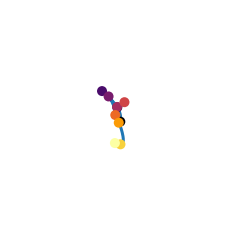

In [17]:
fig=tr.plot_2d_proj(tr.points_from_traces(traces,[200])[0], limits = (-500,500))

Number of traces in heatmap:  884


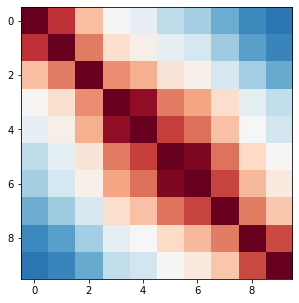

In [29]:
dist, fig = tr.plot_heatmap(traces, zmin = 150, zmax=900)
plt.savefig(r'M:\ChromatinTeam\Random_coils\\'+prefix+'_dist.pdf', format='pdf', dpi=1200, transparent=True)

In [6]:
pwds = tr.pwd_calc(traces)
a = np.triu(np.nanstd(pwds, axis=0)/np.nanmean(pwds, axis=0), k=1)
a = a[a>0]
np.mean(a)

<ipython-input-6-46f925ca1a0f>:2: RuntimeWarning:

invalid value encountered in true_divide



0.45006230873946806

In [32]:
aligned, mean_trace, std_trace = tr.general_procrustes_analysis(traces, traces.trace_ID.unique())

Initial distance:  478765.1992408026
Number of traces:  884
c:\git\pychrtrace\pychrtrace\trace_analysis_functions.py:610: NumbaPerformanceWarning:

'@' is faster on contiguous arrays, called on (array(float64, 2d, C), array(float64, 2d, A))

C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\numba\core\typing\npydecl.py:937: NumbaPerformanceWarning:

'@' is faster on contiguous arrays, called on (array(float64, 2d, C), array(float64, 2d, A))

c:\git\pychrtrace\pychrtrace\trace_analysis_functions.py:610: NumbaPerformanceWarning:

'@' is faster on contiguous arrays, called on (array(float64, 2d, C), array(float64, 2d, A))

C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\numba\core\typing\npydecl.py:937: NumbaPerformanceWarning:

'@' is faster on contiguous arrays, called on (array(float64, 2d, C), array(float64, 2d, A))

GPA converged after 10 cycles with distance 122105.95336234155.


C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\seaborn\distributions.py:1182: UserWarning:

The following kwargs were not used by contour: 'clip_on'

C:\Users\ellenberg\miniconda3\envs\pychrtrace\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



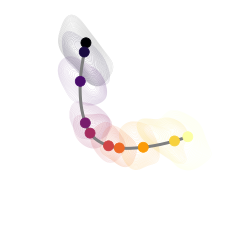

In [36]:
fig =tr.plot_2d_proj_kde(mean_trace, aligned, limits = (-600,600), line_color='#7f7f7f')
plt.savefig(r'M:\ChromatinTeam\Random_coils\\'+prefix+'_2d_proj_kde.pdf', format='pdf', dpi=1200, transparent=True, bbox_inches='tight')